In [397]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns


# KGE boxplot:

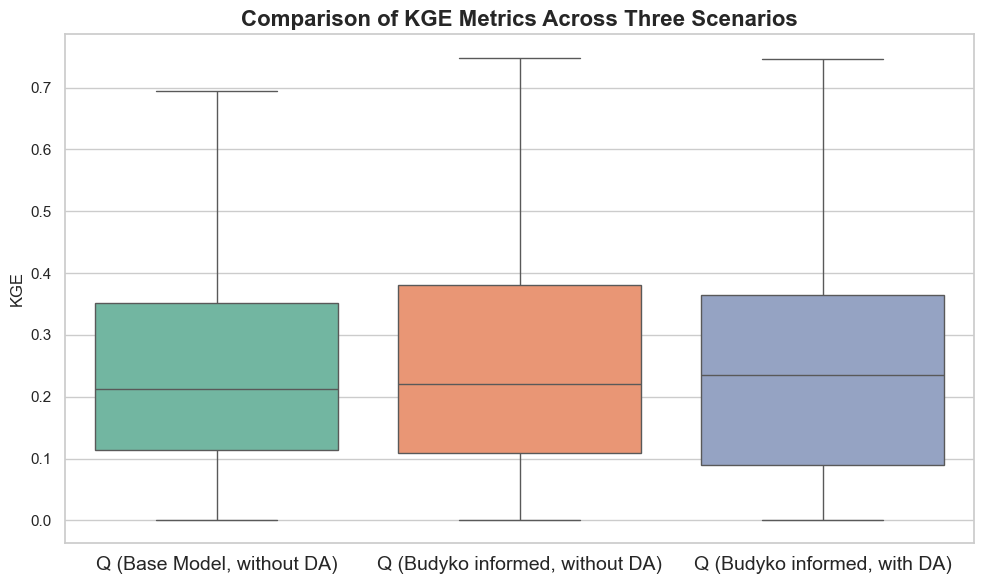

In [398]:

df = pd.read_csv(r'C:\Users\hdagne1\Box\Dr.Mesfin Research\Codes\DA\DA_Github_repo\Bayesian_DA_Budyko_modeling\Simulation_results\enkf_performance_metrics.csv')
df.set_index('gauge_id', inplace=True)

kge_cols = ['Q_Base_Q_KGE', 'Q_B_Q_KGE', 'Q_ET_DA_Q_KGE']
labels = ['Q (Base Model, without DA)', 
          'Q (Budyko informed, without DA)', 
          'Q (Budyko informed, with DA)']

# Replace inf values and keep only positive values
df_clean = df[kge_cols].replace([np.inf, -np.inf], np.nan).dropna()
df_positive = df_clean[df_clean > 0]

# Plot
sns.set(style="whitegrid")
plt.figure(figsize=(10,6))
sns.boxplot(data=df_positive, palette="Set2", showfliers=False)

# Correctly set x-axis labels
plt.xticks(ticks=range(len(labels)), labels=labels, rotation=0, fontsize=14)
plt.ylabel("KGE", fontsize=12)
plt.title("Comparison of KGE Metrics Across Three Scenarios", fontsize=16, fontweight='bold')
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()


# CDF KGE:

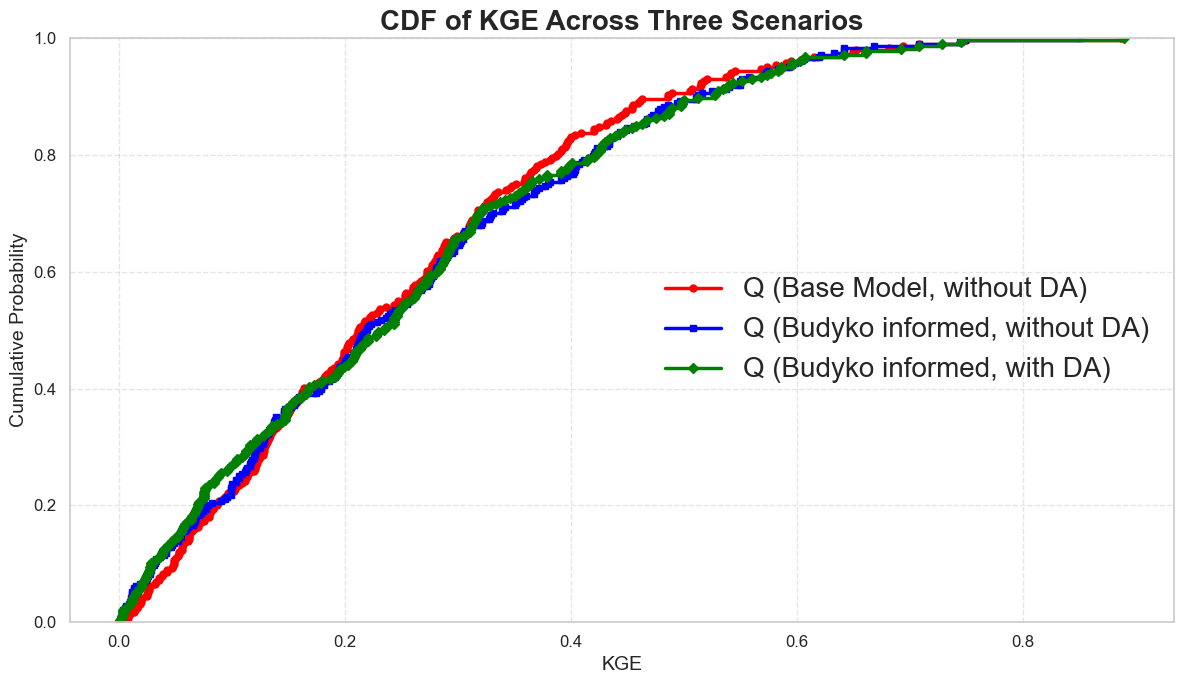

In [399]:
df_positive = df_clean[df_clean > 0]
# Custom styling for lines
# line_styles = ['-', '--', ':']
markers = ['o', 's', 'D']
colors = ['red', 'blue', 'green']
labels = ['Q (Base Model, without DA)', 'Q (Budyko informed, without DA)', 'Q (Budyko informed, with DA)']
# Plot CDF
sns.set(style="whitegrid")
plt.figure(figsize=(12,7))

for i, col in enumerate(df_positive.columns):
    sns.ecdfplot(
        df_positive[col],
        label=col,
        linewidth=2.5,
        # linestyle=line_styles[i],
        color=colors[i],
        marker=markers[i],
        markersize=5
    )

plt.title("CDF of KGE Across Three Scenarios", fontsize=20, fontweight='bold')
plt.xlabel("KGE", fontsize=14)
plt.ylabel("Cumulative Probability", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=20,loc='center right', labels=labels, frameon=False)
plt.tight_layout()
plt.show()


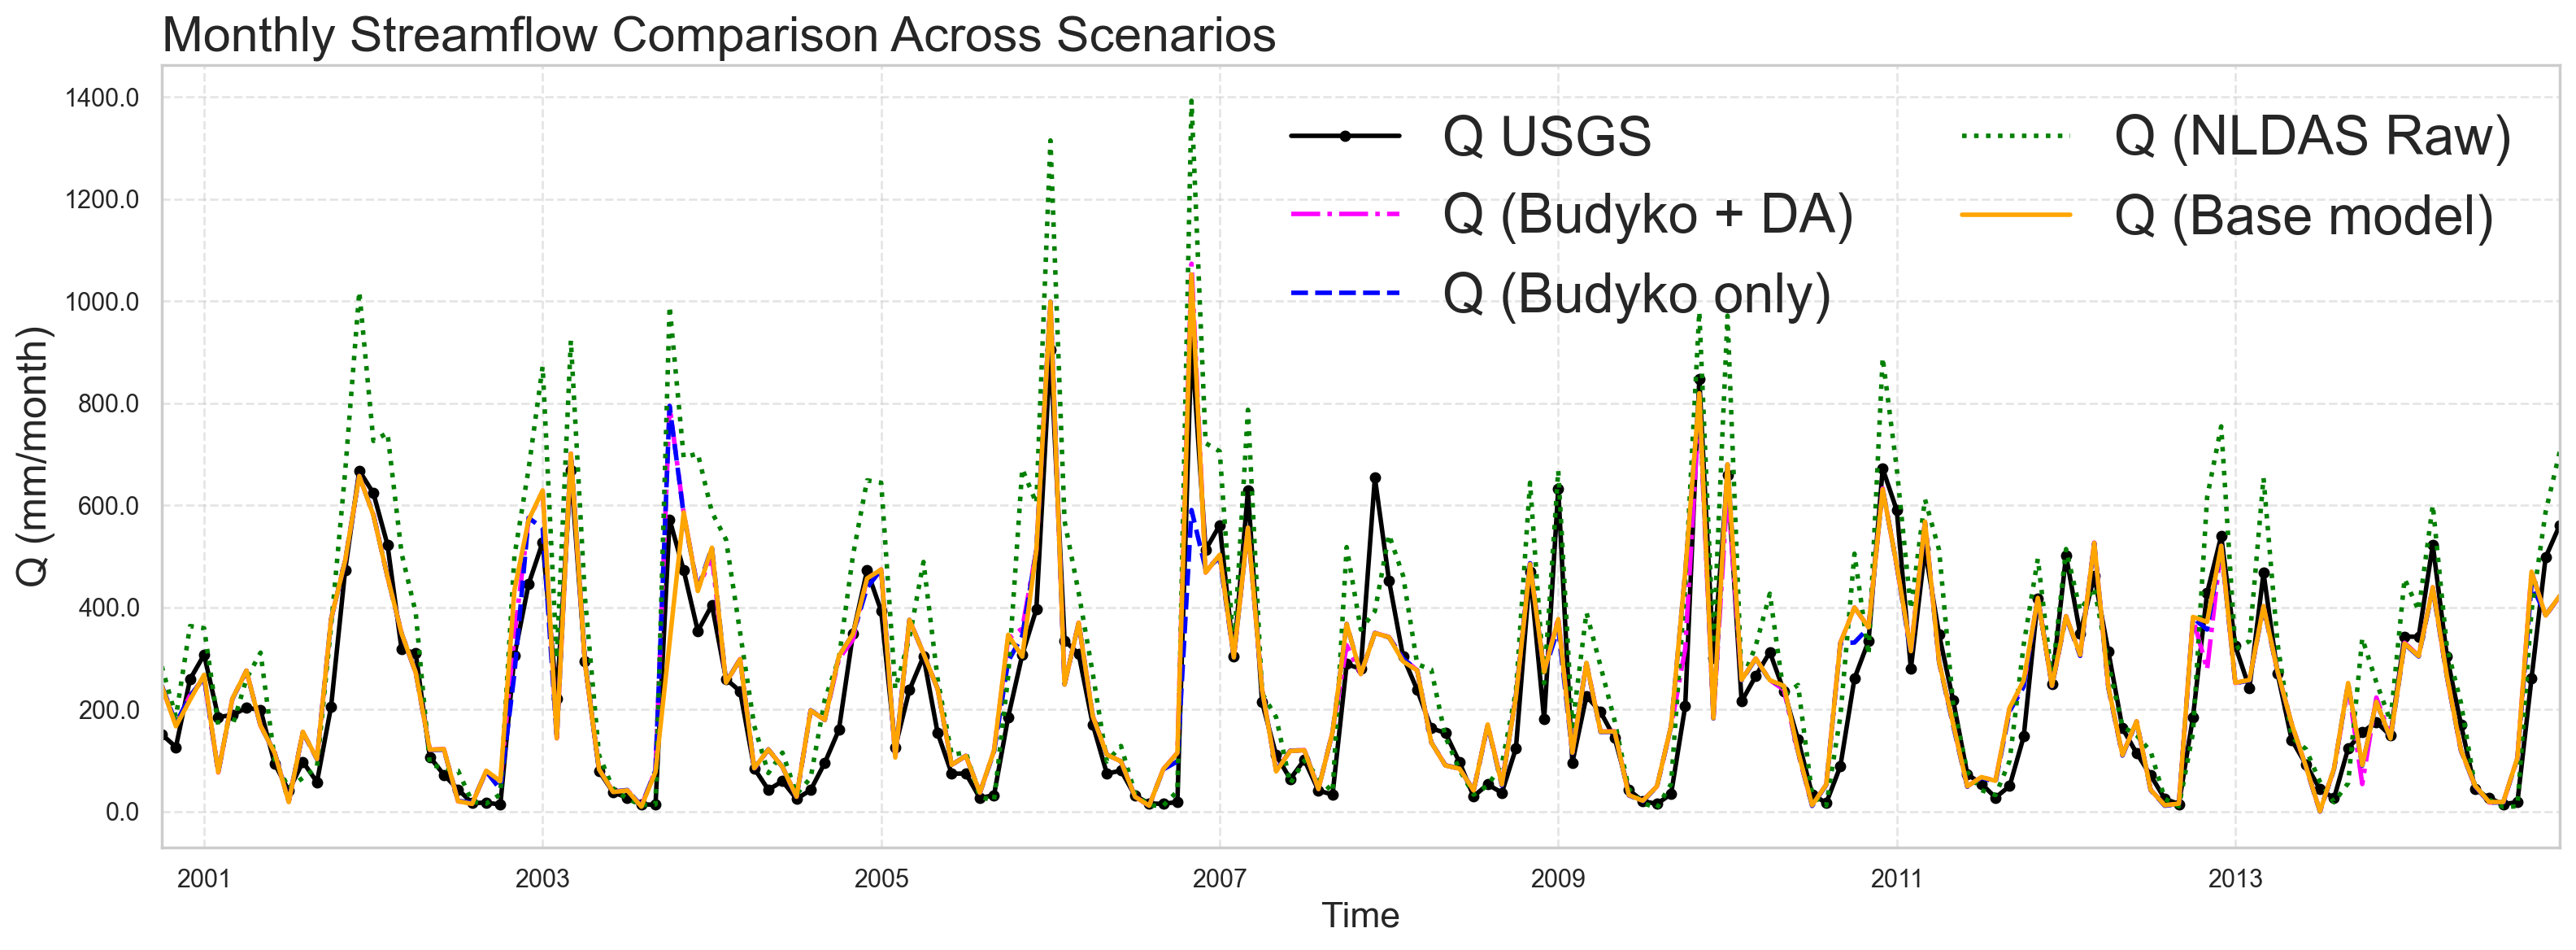

In [400]:
import matplotlib.ticker as mtick
Result_DIR = r"C:\Users\hdagne1\Box\Dr.Mesfin Research\Codes\DA\DA_Github_repo\Bayesian_DA_Budyko_modeling\Simulation_results\enkf_timeseries"
df = pd.read_feather(os.path.join(Result_DIR, "12043000_enkf_timeseries.feather"))

df.set_index('Date', inplace=True)
df = df.loc['2000-10-01':'2014-12-01']

plt.figure(figsize=(16, 6), dpi=200)

# Plot each scenario with improved aesthetics
df['Q_USGS_obs'].plot(label='Q USGS', color='black', lw=2, linestyle='-', marker='o', markersize=4)
df['Q_ET_DA_Q_sim'].plot(label='Q (Budyko + DA)', color='magenta', linestyle='-.', lw=2)
df['Q_B_Q_sim'].plot(label='Q (Budyko only)', color='blue', linestyle='--', lw=2)
df['Q_NLDAS_input'].plot(label='Q (NLDAS Raw)', color='green', linestyle=':', lw=2)
df['Q_Base_Q_sim'].plot(label='Q (Base model)', color='orange', linestyle='-', lw=2)

# Labels, title, and legend
plt.xlabel('Time', fontsize=16)
plt.ylabel('Q (mm/month)', fontsize=18)
plt.title('Monthly Streamflow Comparison Across Scenarios', fontsize=22, loc='left')

# Scientific formatting of y-axis
plt.gca().yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f'))

# Grid, minor ticks, and legend styling
plt.grid(True, which='major', linestyle='--', alpha=0.5)
plt.minorticks_on()
plt.legend(fontsize=24, frameon=0, loc='upper right', ncol=2)

plt.tight_layout()
plt.show()


# NWM data: